In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
from analysis.utils import load_sweep_metadata, load_data

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


In [3]:
df_metadata = load_sweep_metadata(
    "logs/25-11-28-initial_conditions_seeds_sweep")
df = load_data(df_metadata)

Dirs in logs/25-11-28-initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 333.50it/s]


Found 275 configurations
Found 275 configurations


100%|██████████| 275/275 [00:01<00:00, 152.02it/s]


In [ ]:
df_metadata['initial_state'].apply(lambda x: x[0]).unique()
print("Unique cart positions:",
      df_metadata['initial_state'].apply(lambda x: x[0]).unique())
print("Unique pole angles:",
      df_metadata['initial_state'].apply(lambda x: x[1]).unique())

Unique cart positions: [-1.5  1.5 -1.   1.   0. ]
Unique pole angles: [5.65486678 0.62831853 0.         5.02654825 3.76991118 2.51327412
 6.28318531 3.14159265 1.25663706 4.39822972 1.88495559]


In [5]:
activations = np.concatenate(df['latent_states'].tolist())
activations_tensor = torch.from_numpy(activations).float()
activations.shape

(137500, 512)

In [6]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, decoder_bias=True):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim, bias=decoder_bias)

        # Initialize the decoder weights (columns) to have unit norm
        with torch.no_grad():
            # 1. CORRECTED: Use nonlinearity='relu' for Kaiming initialization
            nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')

            # 2. Tie the weights (W_dec = W_enc^T) initially
            self.decoder.weight.data.copy_(self.encoder.weight.data.T)

            # 3. Normalize the decoder weights (columns)
            self.decoder.weight.data.copy_(
                F.normalize(self.decoder.weight.data, dim=0))

            # Optional: Initialize biases to zero
            if self.encoder.bias is not None:
                nn.init.constant_(self.encoder.bias, 0.0)
            if self.decoder.bias is not None:
                nn.init.constant_(self.decoder.bias, 0.0)

    def forward(self, x):
        pre_relu_h = self.encoder(x)
        h = F.relu(pre_relu_h)
        reconstruction = self.decoder(h)

        return h, reconstruction

In [7]:
# 3. Calculate Global Mean
# The mean is calculated along dimension 0 (the sample dimension, N)
# This results in a 1D tensor of shape (D,)
global_mean = activations_tensor.mean(dim=0)
print(f"Global Mean Shape: {global_mean.shape}")

# 4. Perform Mean Subtraction (Centering)
# PyTorch broadcasting automatically handles subtracting the (D,) mean from the (N, D) tensor
normalized_activations = activations_tensor - global_mean

Global Mean Shape: torch.Size([512])


In [12]:
# --- DATALOADER PARAMETERS ---
BATCH_SIZE = 4096
# Using a large batch size helps gather diverse samples and overcome autocorrelation

# 1. Create TensorDataset
# The TensorDataset bundles your feature tensor(s). Since this is unsupervised,
# you only need the activation tensor.
sae_dataset = TensorDataset(normalized_activations)

# 2. Create DataLoader
# This is an iterable that yields shuffled minibatches
sae_dataloader = DataLoader(
    dataset=sae_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Essential: breaks the temporal correlation
    num_workers=4,  # Use more workers for faster data loading (if using CPU)
    pin_memory=True  # Faster data transfer to GPU
)

print(f"Total number of samples: {len(sae_dataset)}")
print(f"Total number of batches (iterations per epoch): {len(sae_dataloader)}")
print("-" * 30)

Total number of samples: 137500
Total number of batches (iterations per epoch): 34
------------------------------


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
def sae_loss(x, x_hat, h, l1_lambda):
    # 1. Reconstruction Loss (MSE)
    # Mean across the batch dimension (N)
    reconstruction_loss = F.mse_loss(x_hat, x)

    # 2. Sparsity Penalty (L1)
    # Sum of absolute values of the sparse features (h), then mean across the batch
    # The L1 is calculated *after* the ReLU (on h)
    l1_loss = torch.mean(torch.sum(h.abs(), dim=-1))

    # 3. Total Loss
    total_loss = reconstruction_loss + l1_lambda * l1_loss

    return total_loss, reconstruction_loss, l1_loss

In [14]:
def train_saes_for_lambdas_and_Ms(activations_tensor,
                                  sae_dataloader,
                                  M_list,
                                  L1_LAMBDA_list,
                                  epochs=5,
                                  learning_rate=1e-3,
                                  verbose=True):
    """
    Trains SAE models for different hidden sizes (M_list) and sparsity parameters (L1_LAMBDA_list).

    Returns:
        results: dict mapping (M, L1_LAMBDA) -> dict of model, losses, etc.
    """
    D = activations_tensor.shape[1]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results = {}

    for M in M_list:
        for L1_LAMBDA in L1_LAMBDA_list:
            # --- Model, Optimizer, and Setup ---
            model = SparseAutoencoder(D, M).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            epoch_losses = []
            epoch_recon_losses = []
            epoch_l1_losses = []

            if verbose:
                print(
                    f"Training SAE: input_dim={D}, hidden={M}, L1_LAMBDA={L1_LAMBDA}"
                )

            for epoch in range(epochs):
                total_loss = 0.0
                total_recon = 0.0
                total_l1 = 0.0
                n_batches = 0

                for batch_idx, (data,) in enumerate(sae_dataloader):
                    data = data.to(device)

                    # Forward pass
                    h, reconstruction = model(data)

                    # Calculate loss
                    loss, recon_loss, l1_loss = sae_loss(
                        data, reconstruction, h, L1_LAMBDA)

                    # Backward pass and optimization
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()
                    total_recon += recon_loss.item()
                    total_l1 += l1_loss.item()
                    n_batches += 1

                    # Optional: Print/Log metrics
                    if verbose and batch_idx % 100 == 0:
                        print(
                            f"[M={M} | L1={L1_LAMBDA}] E:{epoch+1} B:{batch_idx} | Total Loss: {loss.item():.4f} | Recon Loss: {recon_loss.item():.4f} | L1 Loss: {l1_loss.item():.4f}"
                        )

                # Store average losses for the epoch
                epoch_losses.append(total_loss / n_batches)
                epoch_recon_losses.append(total_recon / n_batches)
                epoch_l1_losses.append(total_l1 / n_batches)

            # Store model and losses for later evaluation
            results[(M, L1_LAMBDA)] = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'losses': epoch_losses,
                'recon_losses': epoch_recon_losses,
                'l1_losses': epoch_l1_losses,
            }

    return results


In [15]:
# Example usage, define your grid!
M_list = [32, 64, 128, 256, 512, 1024, 2048, 4096]
L1_LAMBDA_list = [0, 1e-4, 1e-3, 1e-2, 1e-1]
results = train_saes_for_lambdas_and_Ms(
    activations_tensor,
    sae_dataloader,
    M_list,
    L1_LAMBDA_list,
)


Training SAE: input_dim=512, hidden=32, L1_LAMBDA=0


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[M=32 | L1=0] E:1 B:0 | Total Loss: 0.0143 | Recon Loss: 0.0143 | L1 Loss: 2.0553
[M=32 | L1=0] E:2 B:0 | Total Loss: 0.0051 | Recon Loss: 0.0051 | L1 Loss: 5.7627
[M=32 | L1=0] E:3 B:0 | Total Loss: 0.0028 | Recon Loss: 0.0028 | L1 Loss: 6.4606
[M=32 | L1=0] E:4 B:0 | Total Loss: 0.0019 | Recon Loss: 0.0019 | L1 Loss: 7.2504
[M=32 | L1=0] E:5 B:0 | Total Loss: 0.0014 | Recon Loss: 0.0014 | L1 Loss: 7.6400
Training SAE: input_dim=512, hidden=32, L1_LAMBDA=0.0001
[M=32 | L1=0.0001] E:1 B:0 | Total Loss: 0.0140 | Recon Loss: 0.0138 | L1 Loss: 2.0551
[M=32 | L1=0.0001] E:2 B:0 | Total Loss: 0.0057 | Recon Loss: 0.0052 | L1 Loss: 5.2751
[M=32 | L1=0.0001] E:3 B:0 | Total Loss: 0.0033 | Recon Loss: 0.0028 | L1 Loss: 5.3078
[M=32 | L1=0.0001] E:4 B:0 | Total Loss: 0.0025 | Recon Loss: 0.0020 | L1 Loss: 5.4146
[M=32 | L1=0.0001] E:5 B:0 | Total Loss: 0.0020 | Recon Loss: 0.0015 | L1 Loss: 5.1705
Training SAE: input_dim=512, hidden=32, L1_LAMBDA=0.001
[M=32 | L1=0.001] E:1 B:0 | Total Loss: 0.

In [8]:
import pickle

sae_results_sweep_v2_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs/sae_results_sweep_v2.pkl"
with open(sae_results_sweep_v2_path, "rb") as f:
    results = pickle.load(f)


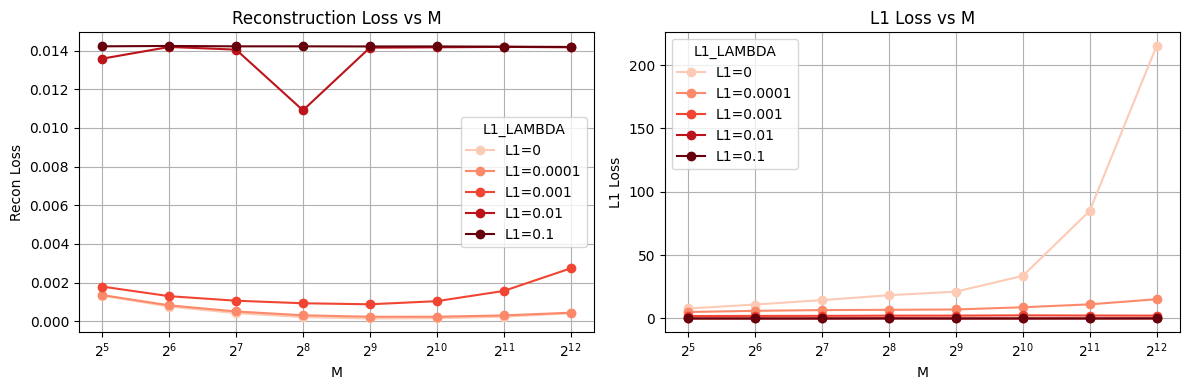

In [9]:
import matplotlib.pyplot as plt
import numpy as np

L1_LAMBDA_list_plot = [0, 1e-4, 1e-3, 1e-2, 1e-1]
M_list = [32, 64, 128, 256, 512, 1024, 2048, 4096]

# Prepare data for each lambda
all_recon_losses = []
all_l1_losses = []
for L1_LAMBDA in L1_LAMBDA_list_plot:
    recon_losses = []
    l1_losses = []
    for M in M_list:
        key = (M, L1_LAMBDA)
        recon = results[key]['recon_losses'][-1]
        l1 = results[key]['l1_losses'][-1]
        recon_losses.append(recon)
        l1_losses.append(l1)
    all_recon_losses.append(recon_losses)
    all_l1_losses.append(l1_losses)

# Use the Reds colormap
cmap = plt.get_cmap('Reds')
colors = [
    cmap(i / (len(L1_LAMBDA_list_plot)) + 0.2)
    for i in range(len(L1_LAMBDA_list_plot))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Reconstruction Loss vs M for all lambdas
for idx, (recon_losses,
          L1_LAMBDA) in enumerate(zip(all_recon_losses, L1_LAMBDA_list_plot)):
    axes[0].plot(M_list,
                 recon_losses,
                 marker='o',
                 label=f"L1={L1_LAMBDA}",
                 color=colors[idx])
axes[0].set_title("Reconstruction Loss vs M")
axes[0].set_xlabel("M")
axes[0].set_ylabel("Recon Loss")
axes[0].set_xscale("log", base=2)
axes[0].grid(True)
axes[0].legend(title="L1_LAMBDA")

# Right: L1 Loss vs M for all lambdas
for idx, (l1_losses,
          L1_LAMBDA) in enumerate(zip(all_l1_losses, L1_LAMBDA_list_plot)):
    axes[1].plot(M_list,
                 l1_losses,
                 marker='o',
                 label=f"L1={L1_LAMBDA}",
                 color=colors[idx])
axes[1].set_title("L1 Loss vs M")
axes[1].set_xlabel("M")
axes[1].set_ylabel("L1 Loss")
axes[1].set_xscale("log", base=2)
axes[1].grid(True)
axes[1].legend(title="L1_LAMBDA")

plt.tight_layout()
plt.show()


In [10]:
# Placeholders for storing results
avg_recon_losses = {M: [] for M in M_list}
avg_active_counts = {M: [] for M in M_list}

# NOTE: Assuming there are utility functions or code to:
# - Load the model for a given (M, L1_LAMBDA)
# - Get your evaluation dataset (e.g. val_loader)
# - Calculate recon loss for each batch [(output, target)]
# - Access the activations from the autoencoder bottleneck
D = activations_tensor.shape[1]
# Loop over all L1_LAMBDA and M values
results_inference = {}
for M in M_list:
    for L1_LAMBDA in L1_LAMBDA_list_plot:
        print(f"M={M}, L1_LAMBDA={L1_LAMBDA}")
        model_state_dict = results[(M, L1_LAMBDA)]['model_state_dict']

        with torch.no_grad():
            model = SparseAutoencoder(D, M).to('cuda')
            model.load_state_dict(model_state_dict)
            model.eval()

            h, reconstruction = model(normalized_activations.to('cuda'))
            h = h.detach().cpu()
            loss = torch.nn.functional.mse_loss(
                reconstruction,
                normalized_activations.to('cuda'),
                reduction='none').detach().cpu().numpy()
            loss_per_sample = loss.mean(1)
            is_active = (torch.abs(h) > 0.05).float()
            active_per_sample = is_active.sum(dim=1)
            results_inference[(M, L1_LAMBDA)] = {
                'recon_losses': loss_per_sample,
                'active_counts': active_per_sample,
                'avg_recon_loss': loss_per_sample.mean(),
                'avg_active_count': active_per_sample.mean(),
            }

        del model
        torch.cuda.empty_cache()

M=32, L1_LAMBDA=0
M=32, L1_LAMBDA=0.0001
M=32, L1_LAMBDA=0.001
M=32, L1_LAMBDA=0.01
M=32, L1_LAMBDA=0.1
M=64, L1_LAMBDA=0
M=64, L1_LAMBDA=0.0001
M=64, L1_LAMBDA=0.001
M=64, L1_LAMBDA=0.01
M=64, L1_LAMBDA=0.1
M=128, L1_LAMBDA=0
M=128, L1_LAMBDA=0.0001
M=128, L1_LAMBDA=0.001
M=128, L1_LAMBDA=0.01
M=128, L1_LAMBDA=0.1
M=256, L1_LAMBDA=0
M=256, L1_LAMBDA=0.0001
M=256, L1_LAMBDA=0.001
M=256, L1_LAMBDA=0.01
M=256, L1_LAMBDA=0.1
M=512, L1_LAMBDA=0
M=512, L1_LAMBDA=0.0001
M=512, L1_LAMBDA=0.001
M=512, L1_LAMBDA=0.01
M=512, L1_LAMBDA=0.1
M=1024, L1_LAMBDA=0
M=1024, L1_LAMBDA=0.0001
M=1024, L1_LAMBDA=0.001
M=1024, L1_LAMBDA=0.01
M=1024, L1_LAMBDA=0.1
M=2048, L1_LAMBDA=0
M=2048, L1_LAMBDA=0.0001
M=2048, L1_LAMBDA=0.001
M=2048, L1_LAMBDA=0.01
M=2048, L1_LAMBDA=0.1
M=4096, L1_LAMBDA=0
M=4096, L1_LAMBDA=0.0001
M=4096, L1_LAMBDA=0.001
M=4096, L1_LAMBDA=0.01
M=4096, L1_LAMBDA=0.1


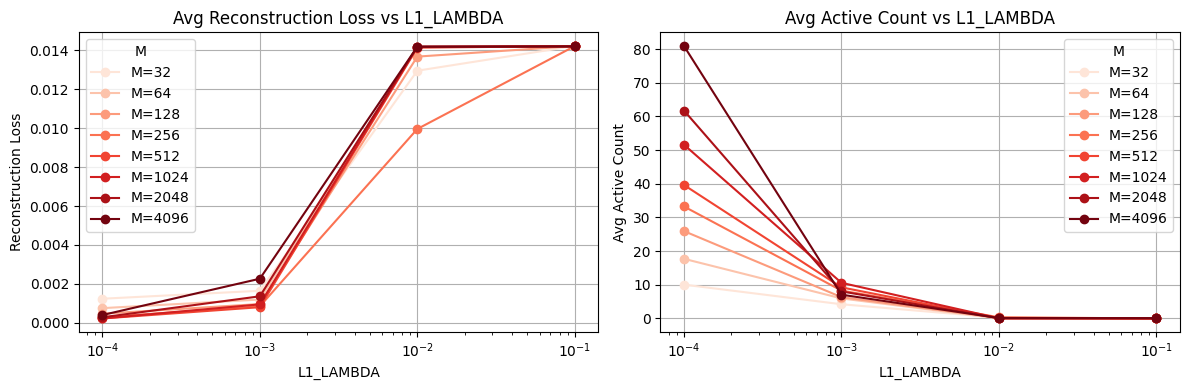

In [15]:
# Plotting based on results_inference structure
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

L1_LAMBDA_list_plot = [0.0001, 0.001, 0.01, 0.1]
L1_LAMBDA_labels = ["1e-4", "1e-3", "1e-2", "1e-1"]  # readable x labels

reds = plt.get_cmap('Reds')
num_M = len(M_list)
colors = [reds(i / (num_M) + 0.1) for i in range(num_M)]

# Collect values from results_inference
# Structure: results_inference[(M, L1_LAMBDA)] -> {'avg_recon_loss': ..., 'avg_active_count': ...}
for idx, M in enumerate(M_list):
    recon_losses = []
    active_counts = []
    for L1_LAMBDA in L1_LAMBDA_list_plot:
        entry = results_inference.get((M, L1_LAMBDA), None)
        if entry is not None:
            recon_losses.append(float(entry['avg_recon_loss']))
            active_counts.append(float(entry['avg_active_count']))
        else:
            recon_losses.append(float('nan'))
            active_counts.append(float('nan'))
    axes[0].plot(L1_LAMBDA_list_plot,
                 recon_losses,
                 marker='o',
                 label=f"M={M}",
                 color=colors[idx])
    axes[1].plot(L1_LAMBDA_list_plot,
                 active_counts,
                 marker='o',
                 label=f"M={M}",
                 color=colors[idx])

axes[0].set_title("Avg Reconstruction Loss vs L1_LAMBDA")
axes[0].set_xlabel("L1_LAMBDA")
axes[0].set_ylabel("Reconstruction Loss")
axes[0].set_xticks(L1_LAMBDA_list_plot)
axes[0].set_xticklabels(L1_LAMBDA_labels)
axes[0].set_xscale("log")
axes[0].legend(title="M")
axes[0].grid(True)

axes[1].set_title("Avg Active Count vs L1_LAMBDA")
axes[1].set_xlabel("L1_LAMBDA")
axes[1].set_ylabel("Avg Active Count")
axes[1].set_xticks(L1_LAMBDA_list_plot)
axes[1].set_xticklabels(L1_LAMBDA_labels)
axes[1].set_xscale("log")
axes[1].legend(title="M")
axes[1].grid(True)

plt.tight_layout()
plt.show()


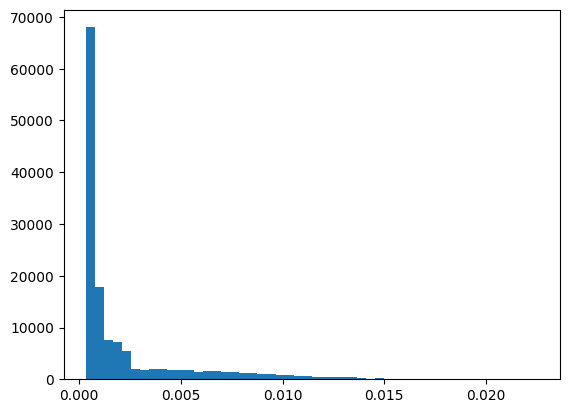

In [22]:
plt.hist(results_inference[(4096, 1e-3)]['recon_losses'], bins=50)
plt.show()